In [1]:
import os
os.environ["NEUROSCALE"] = os.path.expanduser("~/Documents/Github/nscale/NeuroScale")
import networkx as nx
import numpy as np
import pandas as pd
import random
from flow_utils import *

from fugu.scaffold.scaffold import Scaffold
from fugu.bricks.bricks import Brick
from fugu.backends.snn_backend import snn_Backend

# Get the absolute path of the current script
os.getcwd()

def spikes_to_json(result_dict, num_neurons):
    matrix = result_dict.to_numpy()
    spike_times = {}
    for i in range(num_neurons):
        spike_times[i] = []
    for i in matrix:
        spike_times[i[1]].append(int(i[0]))
    return spike_times

# 1. Test Network
- 200 neuros
- bias of 1
- threshold of 100
- edges generated randomly with a 20% probability
- weights of 1
- 500 timesteps

Expected behavior: Synchronized spiking at timestep 99, and then evolving into a randomly spiking wavefront.


In [2]:
# network settings
# 200 neurons, 20% connectivity, 1 weight, bias of 1, threshold of 100, run for 500 time steps
PATH_TO_NSCALE = "~/Documents/Github/nscale/configs/distinct_demo/"
SANA_FE = True
num_neurons = 200
bias = 1
th = 100
prob_w = 0.2
w = 1
time = 500

In [3]:
# connectivity matrix
seed = 42
random.seed(seed)
np.random.seed(seed)

connec_matrix = []
for i in range(num_neurons):
    connec_vector = []
    for j in range(num_neurons):
        if random.random() < prob_w:
            connec_vector.append(1)
        else:
            connec_vector.append(0)
    connec_matrix.append(connec_vector)
#connec_matrix

# 2. Build Brick to Match our Specifications

In [4]:
# making a brick based off of the above settings
class recurrent(Brick):
    def __init__(self, name=None):
        super().__init__()
        self.is_built = False
        self.metadata = {'D':1}  
        self.name = name
    def build(self,
             graph,
             metadata,
             control_nodes,
             input_lists,
             input_codings):

        output_codings = []

        #We also, obviously, need to build the computational portion of our graph
        for i in range(num_neurons):
            graph.add_node(self.name + '_' + str(i),
                           index=i,
                           threshold=th,
                           decay=0.0,
                           bias=bias,
                           p=1.0,
                           potential=0.0
                          )
        for i in range(num_neurons):
            for j in range(num_neurons):
                if connec_matrix[i][j] == 1:
                    graph.add_edge(self.name + '_' + str(i),
                                  self.name + '_' + str(j),
                                  weight=w,
                                  delay=1.0)
        self.is_built=True
        
        # bricks can have more than one output
        output_lists = []
        
        return (graph,
               self.metadata,
                [],
                output_lists,
                output_codings
               )

In [5]:
scaffold = Scaffold()
scaffold.add_brick(recurrent(name='recurrent'), [], output=True)
scaffold.lay_bricks()
#scaffold.summary(verbose=2)

# 3a. Run with SANA-FE Backend

In [ ]:

# get sanafe backend and compile the scaffold
# TODO: move arch YAML file to fugu
from sanafe import fugu as sf
ARCH_FILENAME = "/Users/kamerongano/Documents/Github/SANA-FE/arch/neuroscale.yaml"
MAPPINGS = "core_mappings.json"
#backend = snn_Backend()
sanafe = sf.sanafe_Backend()
backend_args = {}
backend_args['record'] = 'all'
backend_args['arch'] = ARCH_FILENAME
backend_args['mappings'] = MAPPINGS
#backend_args['debug_mode'] = True # show the optential at each time
sanafe.compile(scaffold, backend_args)
sanafe_result = sanafe.run(time)

sanafe_spike_times = spikes_to_json(sanafe_result, num_neurons)
# record the spikes into spikes_fugu.json file
write_json('spikes_fugu.json', sanafe_spike_times, save_to_nscale=True)

fugu:{'index': 0, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 0}
sanafe_props:{'threshold': 100, 'leak_decay': 1.0, 'bias': 1, 'potential': 0.0}
Enabling logging for neuron recurrent_0
fugu:{'index': 1, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 1}
sanafe_props:{'threshold': 100, 'leak_decay': 1.0, 'bias': 1, 'potential': 0.0}
Enabling logging for neuron recurrent_1
fugu:{'index': 2, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 2}
sanafe_props:{'threshold': 100, 'leak_decay': 1.0, 'bias': 1, 'potential': 0.0}
Enabling logging for neuron recurrent_2
fugu:{'index': 3, 'threshold': 100, 'decay': 0.0, 'bias': 1, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-0', 'neuron_number': 3}
sanafe_props:{'threshold': 100, 'leak_decay': 1.0, 'bias': 1, 'potential': 0.0}
Enabling logging for neuron recurrent_3
fugu

# 3b. Run with Vanilla Fugu snn_Backend

In [7]:
# use regular snn backend
vanilla = snn_Backend()
backend_args = {}
backend_args['record'] = 'all'
#backend_args['debug_mode'] = True # show the optential at each time
vanilla.compile(scaffold, backend_args)
vanilla_result = vanilla.run(time)

vanilla_spike_times = spikes_to_json(vanilla_result, num_neurons)
write_json("spikes_vanilla.json", vanilla_spike_times, save_to_nscale=False)

Writing spikes_vanilla.json... to local directory.


# 4. Convert Fugu Scaffold to NeuroScale compatible network representation

In [9]:
scaffold_to_network_json(scaffold.graph, time, "network.json")

# 5. Use network.json to generate NeuroScale compatible mapping
- spikes from both the vanilla and sanafe fugu simulations have been saved in json format

In [10]:
generate_act_network_assets()

Writing core_mappings.json... to local directory.
Writing /Users/kamerongano/Documents/GitHub/nscale/configs/distinct_demo/core_mappings.json... to NeuroScale config.
Writing network_fanin.json... to local directory.
Writing /Users/kamerongano/Documents/GitHub/nscale/configs/distinct_demo/network_fanin.json... to NeuroScale config.
Writing act_network.json... to local directory.
Writing /Users/kamerongano/Documents/GitHub/nscale/configs/distinct_demo/act_network.json... to NeuroScale config.
Writing network_fanin_updated.json... to local directory.
Writing /Users/kamerongano/Documents/GitHub/nscale/configs/distinct_demo/network_fanin_updated.json... to NeuroScale config.
successfully generate act_json/act_network.json


{'network': {'ticks': 500,
  'neuron_dict': {'0': {'fan-in': [3,
     5,
     10,
     19,
     20,
     22,
     25,
     28,
     38,
     42,
     43,
     47,
     53,
     56,
     61,
     71,
     77,
     79,
     83,
     84,
     94,
     106,
     111,
     114,
     115,
     119,
     120,
     121,
     124,
     125,
     137,
     139,
     141,
     144,
     155,
     160,
     161,
     165,
     167,
     178],
    'fan-out': [1,
     7,
     9,
     12,
     13,
     19,
     23,
     26,
     27,
     41,
     44,
     46,
     56,
     58,
     67,
     88,
     89,
     90,
     94,
     100,
     106,
     113,
     119,
     124,
     126,
     131,
     134,
     136,
     139,
     154,
     160,
     165,
     169,
     175,
     176,
     183,
     188,
     197],
    'th': 100,
    'leak': 0.0,
    'bias': 1,
    'refractory period': 0,
    'prob': 1.0,
    'neuron_id': 0},
   '1': {'fan-in': [0,
     7,
     8,
     11,
     17,
     19,
     23,
     27

In [11]:
%%bash
cd "$NEUROSCALE" && make test-sanafe-act


bin/gen_config.py ../configs/distinct_demo/act_network.json > config.dat
echo "cycle" | LD_LIBRARY_PATH=./ actsim -Wlang_subst:off -cnf=sim.conf test.act 'test<>' -DDELTA_W=0 > ../configs/distinct_demo/neuroscale.txt
cd ../configs/distinct_demo && python sanafe_and_act.py
SANA-FE matches with ACTsim


/Users/kamerongano/Documents/GitHub/Fugu_dev/fugu/nscale_flow/act_vanilla_sanafe_overlay.pdf

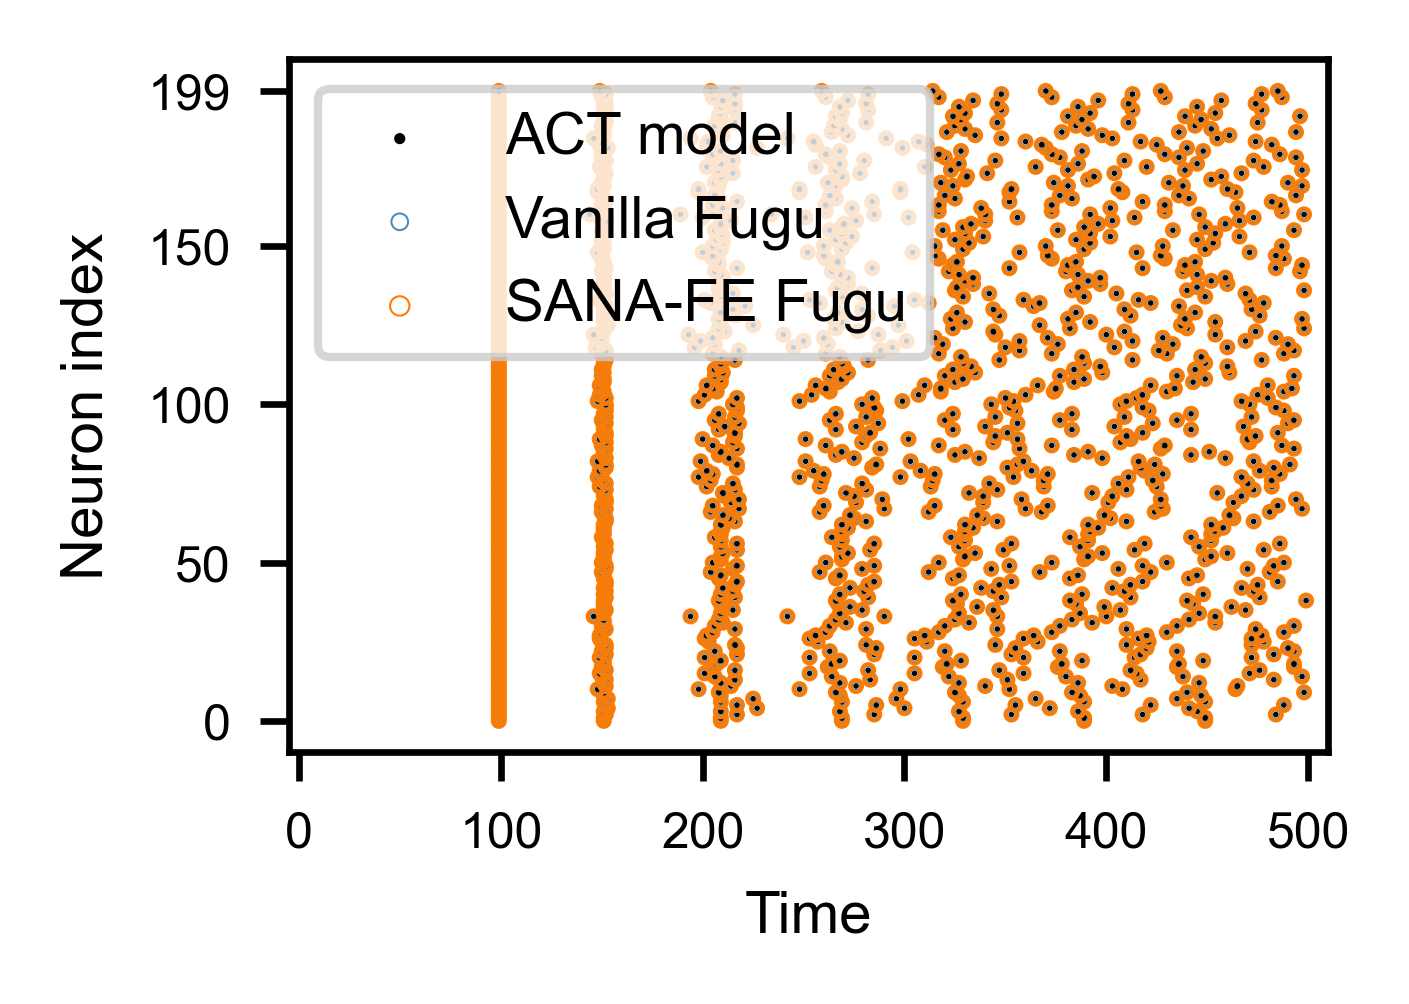

In [13]:
NEUROSCALE_SPIKES = "~/Documents/GitHub/nscale/configs/distinct_demo/neuroscale.txt"
import re
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display, FileLink

# -----------------------------
# 1) Gather spike sources
# -----------------------------
# Vanilla + SANA-FE from current notebook results (preferred)
spikes_vanilla = spikes_to_json(vanilla_result, num_neurons)
spikes_sanafe = spikes_to_json(sanafe_result, num_neurons)

# ACT/NeuroScale text path (use flow.ipynb path variable if present)
neuroscale_txt = os.path.expanduser(
    NEUROSCALE_SPIKES if "NEUROSCALE_SPIKES" in globals()
    else "~/Documents/GitHub/nscale/configs/distinct_demo/neuroscale.txt"
)

# Locate network_fanin mapping (local first, then NSCALE config dir)
fanin_candidates = [
    "network_fanin_updated.json",
    os.path.expanduser("~/Documents/GitHub/nscale/configs/distinct_demo/network_fanin_updated.json"),
]
fanin_path = next((p for p in fanin_candidates if os.path.exists(p)), None)
if fanin_path is None:
    raise FileNotFoundError("Could not find network_fanin_updated.json")

with open(fanin_path, "r") as f:
    neuron_info = json.load(f)["neuron_dict"]

with open(neuroscale_txt, "r") as f:
    act_log = f.read()

# Parse ACT spikes -> global neuron index using core + neuron index mapping
spikes_act = {}
for nid in sorted(neuron_info.keys(), key=int):
    core = neuron_info[nid]["core"]
    neuron_idx = neuron_info[nid]["neuron index"]
    pattern = (
        r"g\.g\[" + str(core[0]) + r"\]\[" + str(core[1]) + r"\]\.C\[" + str(core[2]) +
        r"\].*spike neuron id " + str(neuron_idx) + r" @ (\d+) tick"
    )
    spikes_act[int(nid)] = [int(t) for t in re.findall(pattern, act_log)]

# normalize vanilla/sanafe keys to int
spikes_vanilla = {int(k): v for k, v in spikes_vanilla.items()}
spikes_sanafe = {int(k): v for k, v in spikes_sanafe.items()}

# -----------------------------
# 2) Plot in same style family
# -----------------------------
width_inches = ((88) / 2) / 25.4
height_inches = width_inches / 1.5

plt.style.use("default")
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 7,
    "lines.markersize": 2,
    "figure.dpi": 600,
    "figure.figsize": (width_inches, height_inches),
    "lines.linewidth": 1,
    "axes.linewidth": 0.8,
    "axes.grid": False,
    "savefig.bbox": "tight",
    "savefig.transparent": True,
    "pdf.fonttype": 42,
})

colors = {
    "act": "black",
    "vanilla": "#508CBB",  # blue
    "sanafe": "#Ff7c00",   # orange
}

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])

for i, neuron in enumerate(range(num_neurons)):
    t_act = spikes_act.get(neuron, [])
    t_van = spikes_vanilla.get(neuron, [])
    t_san = spikes_sanafe.get(neuron, [])

    # ACT: black filled dots
    plt.scatter(
        t_act, [i] * len(t_act),
        color=colors["act"], s=0.45, marker="o", edgecolors="none",
        label="ACT model" if i == 0 else ""
    )

    # Vanilla Fugu: blue concentric circles
    plt.scatter(
        t_van, [i] * len(t_van),
        marker="o", facecolor="none", edgecolor=to_rgba(colors["vanilla"]),
        s=1.0, linewidth=0.25,
        label="Vanilla Fugu" if i == 0 else ""
    )
    plt.scatter(
        t_van, [i] * len(t_van),
        marker="o", facecolor="none", edgecolor=to_rgba(colors["vanilla"]),
        s=2.2, linewidth=0.25
    )

    # SANA-FE Fugu: orange concentric circles
    plt.scatter(
        t_san, [i] * len(t_san),
        marker="o", facecolor="none", edgecolor=to_rgba(colors["sanafe"]),
        s=1.35, linewidth=0.25,
        label="SANA-FE Fugu" if i == 0 else ""
    )
    plt.scatter(
        t_san, [i] * len(t_san),
        marker="o", facecolor="none", edgecolor=to_rgba(colors["sanafe"]),
        s=2.8, linewidth=0.25
    )

plt.xlabel("Time")
plt.ylabel("Neuron index")
selected_indices = [0, 50, 100, 150, 199] if num_neurons >= 200 else list(range(0, num_neurons, max(1, num_neurons // 4)))
plt.yticks(selected_indices, selected_indices)
plt.xlim(-5, time + 10)
plt.legend(prop={"family": "Arial"}, loc="upper left", markerscale=2)
plt.grid(False)

with PdfPages("act_vanilla_sanafe_overlay.pdf") as pdf:
    pdf.savefig(bbox_inches="tight")

display(FileLink("act_vanilla_sanafe_overlay.pdf"))